11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch: 1 Generator Loss: 0.6491 Discriminator Loss: 1.1856
Epoch: 2 Generator Loss: 0.8037 Discriminator Loss: 1.2403
Epoch: 3 Generator Loss: 0.8976 Discriminator Loss: 1.2006
Epoch: 4 Generator Loss: 0.7884 Discriminator Loss: 1.3152
Epoch: 5 Generator Loss: 0.8998 Discriminator Loss: 1.2251


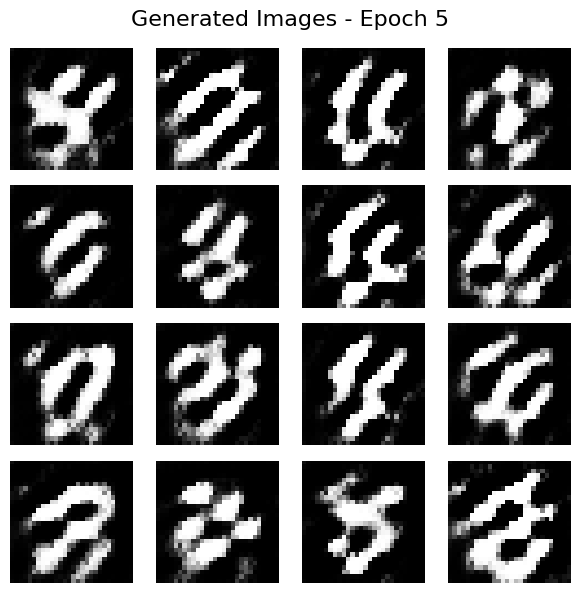

Epoch: 6 Generator Loss: 0.8532 Discriminator Loss: 1.2955
Epoch: 7 Generator Loss: 0.8666 Discriminator Loss: 1.2559
Epoch: 8 Generator Loss: 0.9358 Discriminator Loss: 1.2021
Epoch: 9 Generator Loss: 0.9055 Discriminator Loss: 1.2172
Epoch: 10 Generator Loss: 0.8858 Discriminator Loss: 1.2776


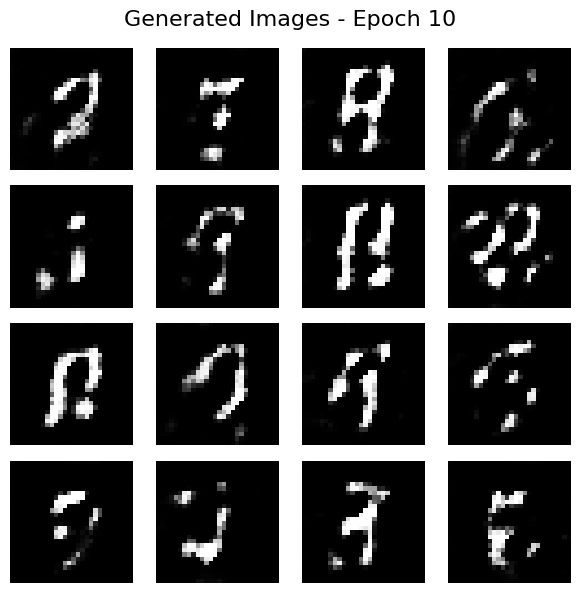

Epoch: 11 Generator Loss: 0.8721 Discriminator Loss: 1.271
Epoch: 12 Generator Loss: 0.9429 Discriminator Loss: 1.2113
Epoch: 13 Generator Loss: 1.0059 Discriminator Loss: 1.1668
Epoch: 14 Generator Loss: 0.9562 Discriminator Loss: 1.2058
Epoch: 15 Generator Loss: 1.0847 Discriminator Loss: 1.1247


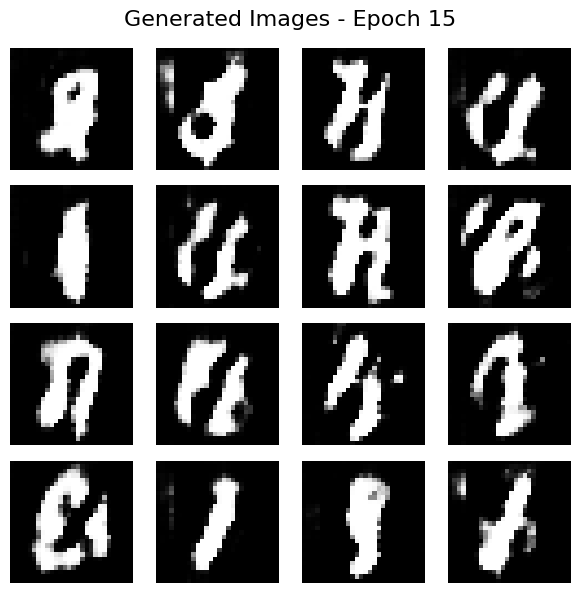

Epoch: 16 Generator Loss: 1.0448 Discriminator Loss: 1.1707


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

(x_train, _), (_, _) = mnist.load_data()

x_train = x_train.reshape(-1, 28, 28, 1).astype("float32")
x_train = (x_train - 127.5) / 127.5

latent_dim = 100
batch_size = 256
EPOCHS = 20
num_examples = 16

generator = keras.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(7 * 7 * 256, use_bias=False),
    layers.BatchNormalization(),
    layers.LeakyReLU(),
    layers.Reshape((7, 7, 256)),
    layers.Conv2DTranspose(
        128,
        (5, 5),
        strides=(1, 1),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),
    layers.Conv2DTranspose(
        64,
        (5, 5),
        strides=(2, 2),
        padding="same",
        use_bias=False
    ),
    layers.BatchNormalization(),
    layers.LeakyReLU(),
    layers.Conv2DTranspose(
        1,
        (5, 5),
        strides=(2, 2),
        padding="same",
        activation="tanh"
    )
])

discriminator = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(
        64,
        (5, 5),
        strides=(2, 2),
        padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),
    layers.Conv2D(
        128,
        (5, 5),
        strides=(2, 2),
        padding="same"
    ),
    layers.LeakyReLU(),
    layers.Dropout(0.3),
    layers.Flatten(),
    layers.Dense(1, activation="sigmoid")
])

cross_entropy = keras.losses.BinaryCrossentropy()

def generator_loss(fake_output):
    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )
    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )
    return real_loss + fake_loss

generator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0001
)

discriminator_optimizer = keras.optimizers.Adam(
    learning_rate=0.0001
)

@tf.function
def train_step(images):
    noise = tf.random.normal(
        [batch_size, latent_dim]
    )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

        generated_images = generator(
            noise,
            training=True
        )

        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    gen_gradients = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    disc_gradients = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    generator_optimizer.apply_gradients(
        zip(
            gen_gradients,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            disc_gradients,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

dataset = tf.data.Dataset.from_tensor_slices(
    x_train
)

dataset = dataset.shuffle(
    60000
).batch(
    batch_size,
    drop_remainder=True
)

seed = tf.random.normal(
    [num_examples, latent_dim]
)

def generate_images(epoch):
    predictions = generator(
        seed,
        training=False
    )

    predictions = (predictions + 1) / 2

    plt.figure(figsize=(6, 6))

    for i in range(num_examples):
        plt.subplot(4, 4, i + 1)
        plt.imshow(
            predictions[i, :, :, 0],
            cmap="gray"
        )
        plt.axis("off")

    plt.suptitle(
        "Generated Images - Epoch " + str(epoch),
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

for epoch in range(EPOCHS):

    generator_losses = []
    discriminator_losses = []

    for image_batch in dataset:

        gen_loss, disc_loss = train_step(
            image_batch
        )

        generator_losses.append(
            gen_loss.numpy()
        )

        discriminator_losses.append(
            disc_loss.numpy()
        )

    avg_gen_loss = np.mean(
        generator_losses
    )

    avg_disc_loss = np.mean(
        discriminator_losses
    )

    print(
        "Epoch:",
        epoch + 1,
        "Generator Loss:",
        round(avg_gen_loss, 4),
        "Discriminator Loss:",
        round(avg_disc_loss, 4)
    )

    if (epoch + 1) in [5, 10, 15, 20]:
        generate_images(
            epoch + 1
        )

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    generator_losses
)

plt.xlabel("Training")
plt.ylabel("Generator Loss")
plt.title("GAN Training")

plt.show()